# Animations and traces

For use for slides and Figures 2, 3, and 4.

Table of Contents:
1. Imports and load data
2. Plot maze (Fig. 2)
3. Trace overlays (Fig. 4)
4. Animations

## 1. Imports and load data

In [22]:
import matplotlib.pyplot as plt
import numpy as np 
import os
import pandas as pd
import warnings

from joblib import Parallel, delayed

from flow_tree_utils import compute_explore_traj, compute_extended_explore_traj, load_test_df

warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None

# Load test data into dataframe
test_df = load_test_df()


#### Explore data

In [11]:
# Load explore data
df = pd.read_csv("data/MLINDIV_train_full.csv")

explore_df = df[df["eprocs"].str.contains("Explore")]

# By quartile
q_dict = {}
acc_dict = {}
for index, row in test_df[["Subject", "quartile", "subj_mean_acc"]].iterrows():
    subj, q, acc = row["Subject"], row["quartile"], row["subj_mean_acc"]
    if subj not in q_dict:
        q_dict[subj] = q
        acc_dict[subj] = acc

explore_df["quartile"] = explore_df["Subject"].map(q_dict)
explore_df["subject_mean_acc"] = explore_df["Subject"].map(acc_dict)

# concatenate explore rounds for now
explore_df["explore_path"] = explore_df.groupby("Subject")["e_paths"].transform(" ".join)
explore_df = explore_df.drop_duplicates(subset=["Subject"], keep="first")

explore_df["extended_explore_traj"] = explore_df["explore_path"].apply(compute_extended_explore_traj)
explore_df["explore_traj"] = explore_df["explore_path"].apply(compute_explore_traj)
explore_df["num_nodes_visited"] = explore_df["explore_traj"].apply(len)

subject_df = pd.read_csv("data/MLINDIV_subject_info.csv")
subject_df["Subject"] = pd.to_numeric(subject_df["Spatial Neuro ID"], errors="coerce")
subject_df = subject_df[~subject_df["Subject"].isna()]

subject_df["is_man"] = (subject_df["Sex"] == "M")

merged_df = pd.merge(explore_df, subject_df, on="Subject")

## 2. Plot maze

#### Helper fns

In [3]:
def draw_maze(ax):
    # starting from upper left
    external_structure = [
        # upper edge
        (0, 12), (2, 12), (2, 10), (3, 10), (3, 12), (12, 12),
        # right edge
        (12, 7), (11, 7), (11, 11), (10, 11), (10, 5), (7, 5), (7, 2), (8, 2), (8, 0),
        # bottom edge
        (6, 0), (6, 1), (7, 1), (7, 1.2), (3, 1.2), (3, 1), (5.5, 1), (5.5, 0), (2, 0), (2, 1), (1, 1),
        # right edge
        (1, 5), (2.9, 5), (2.9, 4), (2, 4), (2, 2), (3, 2), (3, 9), (2, 9), (2, 7), (2.9, 7), (2.9, 6), (1, 6), (1, 11), (0, 11), (0, 12)
    ]

    internal_structures = [
        # lower middle
        [(4, 2), (6, 2), (6, 5), (4, 5), (4, 2)],
        # middle
        [(4, 11), (4, 6), (6, 6), (6, 11), (5, 11), (5, 10), (6, 10), (6, 9), (4, 9)], 
        # upper right
        [(8, 10), (7, 10), (7, 11), (9, 11), (9, 9), (7, 9), (7, 6), (9, 6), (9, 7), (8, 7)]
    ]

    structures = internal_structures + [external_structure]

    for structure in structures:
        x_values, y_values = zip(*structure) # This unzips the start and end points into two tuples
        ax.plot(x_values, y_values, color='black', linewidth=4)

    #plot red objects now
    # red_circle_locations = [(.5, 11.5), (2.5, 4.5), (2.5, 6.5), (5.5, 9.5), (7.5, 10.5), (8.5, 6.5), (11.5, 7.5), (5, .5), (6.5, .5)]
    # for circle_loc in red_circle_locations:
    #     circle = plt.Circle(circle_loc, 0.2, color='r')
    #     ax.add_patch(circle)

    # set limits so that plt doesnt jiggle things when the person triangle reaches the edges
    lims = [-0.5, 12.5]
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    return ax

letter_code_to_coords_nonoffset = {
    "A": (2, 12), "B": (4, 12), "C": (5, 12),
    "D": (7, 12), "E": (10, 12), "F": (12, 12),
    "G": (2, 10), "H": (4, 10), "I": (5, 10),
    "J": (7, 10), "K": (9, 10), "L": (2, 7),
    "M": (10, 9), "N": (12, 9), "O": (8, 7.5),
    "P": (2, 5), "Q": (4, 6), "R": (7, 6),
    "S": (10, 6), "T": (4, 2.2), "U": (7, 2.2),
    "V": (3, 1), "W": (8, 1), "X": (3, 2),
    "Y": (5, 1), "Z": (2, 2)
}

# add offsets
letter_code_to_coords = {k: (v[0]-.7, v[1]-.7) for k,v in letter_code_to_coords_nonoffset.items()}

def add_letters(ax, letter_code_to_coords):
    for letter, (x,y) in letter_code_to_coords.items():
        ax.text(x, y, letter, fontsize=12, color="navy")

    return ax

def add_start_end(ax, start_loc, end_loc):
    circle = plt.Circle((start_loc[0]+.15, start_loc[1]+.15), 0.5, color='g', alpha=0.3)
    ax.add_patch(circle)

    circle = plt.Circle((end_loc[0]+.15, end_loc[1]+.15), 0.5, color='y', alpha=0.2)
    ax.add_patch(circle)

    return ax    

def add_person(ax, loc, dir, correct=True):
    if correct: color="green"
    else: color="red"

    # point in direction of dir
    point1 = (loc[0] + .9 * dir[0], loc[1] + .9 * dir[1])

    # if dir is in y we gotta flare in x
    point2 = (loc[0] - .25 * dir[1], loc[1] - .25 * dir[0])
    point3 = (loc[0] + .25 * dir[1], loc[1] + .25 * dir[0])

    triangle = plt.Polygon([point1, point2, point3], color=color, alpha=.1)
    ax.add_patch(triangle)

    return ax

def add_path_trace(ax, points_traversed,correct=True):
    if correct: color="green"
    else: color="red"

    x_values, y_values = zip(*points_traversed) # This unzips the start and end points into two tuples
    ax.plot(x_values, y_values, color=color, alpha=0.02, linewidth=5)
    return ax

#### Plot plain maze

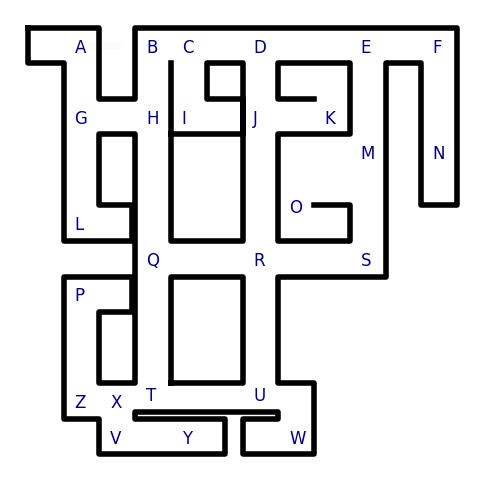

In [4]:
# draw maze in plt
fig, ax = plt.subplots(figsize=(6, 6))

ax = draw_maze(ax)
ax = add_letters(ax, letter_code_to_coords)
# ax = add_start_end(ax, letter_code_to_coords[start_node], letter_code_to_coords[end_node])
# ax = add_person(ax, (1.5, 11.5), (0, -1))
ax = add_path_trace(ax, [(1.5, 11.5), [2.5, 11.5]])

plt.axis('off')
plt.show()
# fig.savefig("figures/plain-maze.png")

## 3. Trace overlay

### Helper fns

In [45]:
number_code_to_dir = {"1": (0 ,1), "2": (1, 0), "3": (0, -1), "4": (-1, 0)}

def generate_trace_overlay(ax, df, start_node, end_node, letter_code_to_coords=letter_code_to_coords, do_draw_maze=False, do_add_letters=True, do_add_start_end=False):
    if do_draw_maze: ax = draw_maze(ax)
    if do_add_letters: ax = add_letters(ax, letter_code_to_coords)
    if do_add_start_end: ax = add_start_end(ax, letter_code_to_coords[start_node], letter_code_to_coords[end_node])

    # GO THROUGH EACH PERSON
    for _, row in df.iterrows():
        path = row["e_paths"] 
        if path[-2:] == "NA": path = path[:-2] # this happens if the test ends unsuccessfully
        
        states = path.split()
        locs = [letter_code_to_coords[start_node]] + [letter_code_to_coords[x[0]] for x in states]

        # Add small random jitter to each point except start/end
        jittered_locs = []
        for j, loc in enumerate(locs):
            if j == 0 or j == len(locs)-1:  # Keep start and end points exact
                jittered_locs.append(loc)
            else:
                jitter = np.random.normal(0, 0.2, 2)  # Small random offset
                jittered_locs.append((loc[0] + jitter[0], loc[1] + jitter[1]))

        x_values, y_values = zip(*jittered_locs)
        ax.plot(x_values, y_values, color="k", alpha=0.25, linewidth=0.6)
    ax.set_axis_off()
    return ax

### Run overlay

NY 67


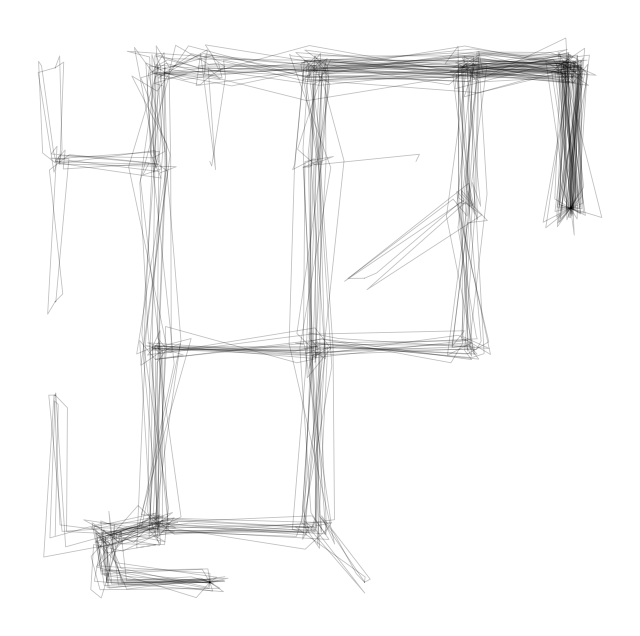

AY 68


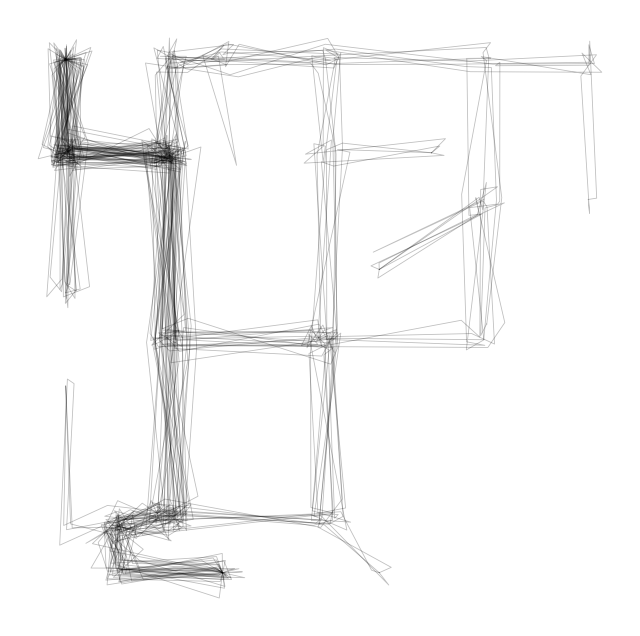

PI 72


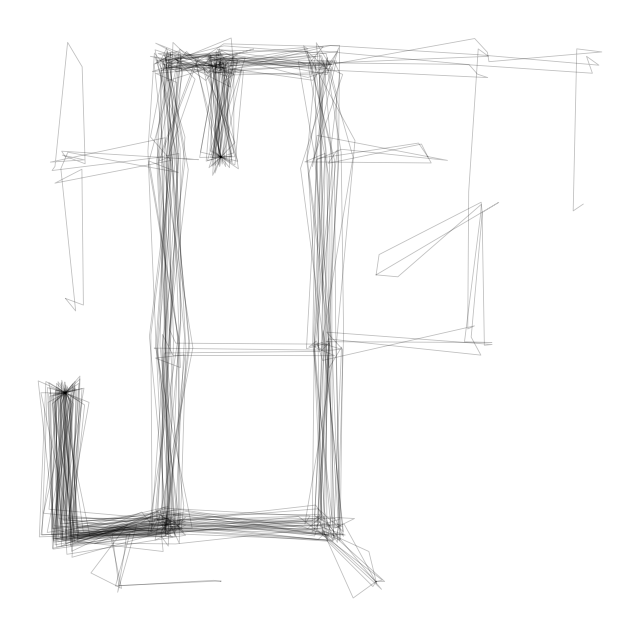

AN 67


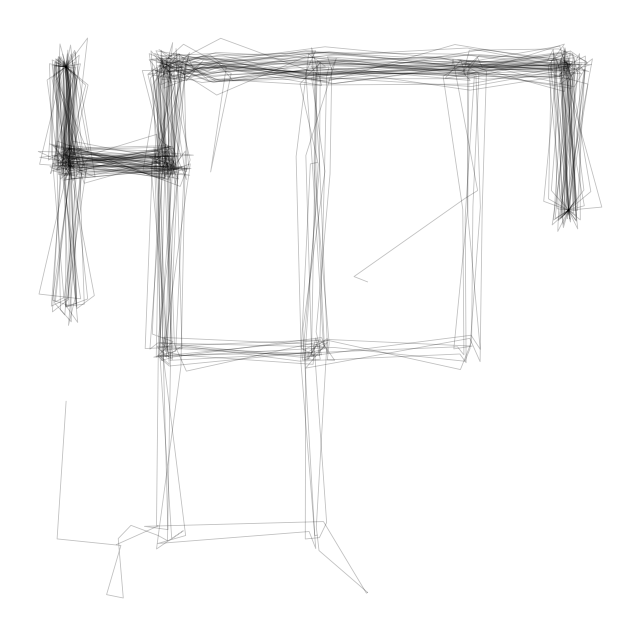

In [46]:
examples = ["NY", "AY", "PI", "AN"]

for example in examples:
    START_NODE, END_NODE = example[0], example[1]
    this_df = df[(df["StartAt"]== START_NODE) & (df["EndAt"] == END_NODE)]

    print(example, len(this_df))
    fig, ax = plt.subplots(figsize=(8, 8))
    ax = generate_trace_overlay(ax, this_df, START_NODE, END_NODE, do_draw_maze=False, do_add_letters=False, do_add_start_end=False)
    plt.show()

## 4. Animations

In [12]:
# create example animation for one path
path = df["e_paths"][2]
print(path)

start_node = df["StartAt"][2]
end_node = df["EndAt"][2]

print(start_node)
print(end_node)


U4 U1 R1 J1 D1 D4 D3 D2 E2 F2 F3 F4 E4 D4 D3 J3 J2 J3
W
N


In [19]:
letter_code_to_coords
number_code_to_dir = {"1": (0 ,1), "2": (1, 0), "3": (0, -1), "4": (-1, 0)}

if path[-2:] == "NA": path = path[:-2]
states = path.split()

print([x[0] for x in states])
print([x[1] for x in states])

locs = [letter_code_to_coords[x[0]] for x in states]
dirs = [number_code_to_dir[x[1]] for x in states]

# cum_paths = [[]]
# for loc in locs:
#     cum_paths.append(cum_paths[-1].copy().extend(locs))

start_loc, end_loc = letter_code_to_coords[start_node], letter_code_to_coords[end_node]

# print("jsdlkf{dir}jklsdjf{dir}".format(dir="   "))

['U', 'U', 'R', 'J', 'D', 'D', 'D', 'D', 'E', 'F', 'F', 'F', 'E', 'D', 'D', 'J', 'J', 'J']
['4', '1', '1', '1', '1', '4', '3', '2', '2', '2', '3', '4', '4', '4', '3', '3', '2', '3']


In [18]:
def generate_image(person_loc, person_dir, i, start_loc=None, end_loc=None, path_trace=None, dir="animation_test", title=""):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax = draw_maze(ax)
    ax = add_letters(ax, letter_code_to_coords)
    ax = add_person(ax, person_loc, person_dir)

    if start_loc is not None and end_loc is not None:
        ax = add_start_end(ax, start_loc, end_loc)

    if path_trace is not None and len(path_trace) > 1:
        ax = add_path_trace(ax, path_trace)
        ax = add_path_trace(ax, [path_trace[-1], person_loc])
    
    ax.set_title(title)
    fig.savefig(f'{dir}/pic{i:04d}.png')
    plt.close()

dir_to_save = "animations/with_trace"
if not os.path.exists(dir_to_save):
    os.makedirs(dir_to_save)

Parallel(n_jobs=-1)(delayed(generate_image)(loc, dir, i, start_loc=start_loc, end_loc=end_loc, path_trace=locs[:i], dir=dir_to_save) for i, (loc, dir) in enumerate(zip(locs, dirs)))

# generate_image(locs[3], dirs[3], 3, start_loc=None, end_loc=None, path_trace=locs[:3], dir=dir_to_save)

# the y overwrites automatically so ipynb doesnt hang
os.system(f'ffmpeg -y -i {dir_to_save}/pic%04d.png -vf palettegen {dir_to_save}/palette.png')
os.system(f'ffmpeg -y -framerate 5 -i {dir_to_save}/pic%04d.png -i {dir_to_save}/palette.png -lavfi paletteuse -framerate 5 {dir_to_save}/aavideo.gif')

sh: ffmpeg: command not found
sh: ffmpeg: command not found


32512

In [10]:
# okay let's make one function for doing one run...

def animate_one_path(row, dir_to_save, letter_code_to_coords=letter_code_to_coords, number_code_to_dir=number_code_to_dir):
    # EXTRACT INFO FROM ROW
    path = row["e_paths"]
    is_test = "Test" in row["eprocs"]
    
    # FIRST CONVERT PATH TO COORDS
    if path[-2:] == "NA": path = path[:-2] # this happens if the test ends unsuccessfully
    states = path.split()

    # THEN GENERATE IMAGE FOR EACH STEP IN PATH
    if is_test:
        locs = [letter_code_to_coords[chr(int(row["startPosition"])+65)]] + [letter_code_to_coords[x[0]] for x in states]
        dirs = [number_code_to_dir[str(int(row["startFacing"]))]] + [number_code_to_dir[x[1]] for x in states]
    
        start_loc, end_loc = letter_code_to_coords[row["StartAt"]], letter_code_to_coords[row["EndAt"]]
        Parallel(n_jobs=-1)(delayed(generate_image)(loc, dir, i, start_loc=start_loc, end_loc=end_loc, path_trace=locs[:i], title=f'test, accuracy={row["accuracy"]}' , dir=dir_to_save) for i, (loc, dir) in enumerate(zip(locs, dirs)))
    else:

        locs = [letter_code_to_coords[x[0]] for x in states]
        dirs = [number_code_to_dir[x[1]] for x in states]

        Parallel(n_jobs=-1)(delayed(generate_image)(loc, dir, i, path_trace=locs[:i], title="explore", dir=dir_to_save) for i, (loc, dir) in enumerate(zip(locs, dirs)))

    # THEN CONVERT TO GIF
    # the y overwrites automatically so ipynb doesnt hang
    os.system(f'ffmpeg -y -i {dir_to_save}/pic%04d.png -vf palettegen {dir_to_save}/palette.png')
    os.system(f'ffmpeg -y -framerate 10 -i {dir_to_save}/pic%04d.png -i {dir_to_save}/palette.png -lavfi paletteuse -framerate 10 {dir_to_save}/aavideo.gif')

# dir_to_save = "with_trace"
# animate_one_path(df.iloc[3], dir_to_save)

In [11]:
explore_df = df[df["eprocs"].str.contains("Explore")]

for i, row in explore_df.iterrows():

    dir_to_save = f"animations/explore/{i}"
    os.makedirs(dir_to_save, exist_ok=True)
    animate_one_path(row, dir_to_save)

sh: ffmpeg: command not found
sh: ffmpeg: command not found
sh: ffmpeg: command not found
sh: ffmpeg: command not found
sh: ffmpeg: command not found
sh: ffmpeg: command not found
sh: ffmpeg: command not found
sh: ffmpeg: command not found
sh: ffmpeg: command not found
sh: ffmpeg: command not found
sh: ffmpeg: command not found
sh: ffmpeg: command not found
sh: ffmpeg: command not found
sh: ffmpeg: command not found
sh: ffmpeg: command not found
sh: ffmpeg: command not found
sh: ffmpeg: command not found
sh: ffmpeg: command not found


KeyboardInterrupt: 

In [8]:
def animate_by_start_end(df, start_node, end_node, dir_to_save, letter_code_to_coords=letter_code_to_coords, number_code_to_dir=number_code_to_dir):
    os.makedirs(dir_to_save, exist_ok=True)

    df_this_path = df[(df["StartAt"] == start_node) & (df["EndAt"] == end_node)]
    # just to make it more tractable for now
    # df_this_path = df_this_path.iloc[:10]

    max_path_len = int(df_this_path["nodesturns_count"].max())

    # generate_multi_path_image(df_this_path, 5, start_node, end_node)
    Parallel(n_jobs=-1)(delayed(generate_multi_path_image)(df_this_path, i, start_node, end_node, dir=dir_to_save) for i in range(max_path_len))
    
    # # THEN CONVERT TO GIF
    # # the y overwrites automatically so ipynb doesnt hang
    os.system(f'ffmpeg -y -i {dir_to_save}/pic%04d.png -vf palettegen {dir_to_save}/palette.png')
    os.system(f'ffmpeg -y -framerate 5 -i {dir_to_save}/pic%04d.png -i {dir_to_save}/palette.png -lavfi paletteuse -framerate 5 {dir_to_save}/aavideo.gif')

# dir_to_save = "multi_test"
# animate_by_start_end(df, start_node="K", end_node="W", dir_to_save=dir_to_save)

In [ ]:
df = pd.read_csv("data/MLINDIV_train_full.csv")

# load test df
test_df = df[df["eprocs"].str.contains("Test")]

test_df["subj_mean_acc"] = test_df.groupby("Subject")["accuracy"].transform("mean")
test_df["path_mean_acc"] = test_df.groupby(["StartAt", "EndAt"])["accuracy"].transform("mean")

test_df['quartile'] = (
    pd.qcut(test_df['subj_mean_acc'], 4, labels=[1, 2, 3, 4])
)

test_df["path_mean_acc_by_Q"] = test_df.groupby(["StartAt", "EndAt", "quartile"])["accuracy"].transform("mean")
test_df["accuracy"] = test_df["accuracy"].astype(bool)

test_df["trajs"] = test_df["paths"].apply(generate_traj_from_path)
test_df["traj_strs"] = test_df["trajs"].apply("".join)


subject_df = pd.read_csv("data/MLINDIV_subject_info.csv")
subject_df["Subject"] = pd.to_numeric(subject_df["Spatial Neuro ID"], errors="coerce")
subject_df = subject_df[~subject_df["Subject"].isna()]

subject_df["is_man"] = (subject_df["Sex"] == "M")

merged_test_df = pd.merge(test_df, subject_df, on="Subject")
# merged_df[["Sex", "Proportion Correct (new version)", "subject_mean_acc"]]

In [ ]:
for start_node, end_node in df.groupby(["StartAt", "EndAt"]).groups.keys():
      print(start_node, end_node)
      animate_by_start_end(df, start_node=start_node, end_node=end_node, dir_to_save=f'animations/test_by_start-end/{start_node+end_node}')
      # break